<a href="https://colab.research.google.com/github/eogks1235-byte/DEEP_Learning-feat.Jake-Oh/blob/main/ml17_ann_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion MNIST 데이터셋 이미지 분류

# IMPORT

In [13]:
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

import tensorflow as tf
import keras

import numpy as np


In [14]:
tf.__version__

'2.19.0'

In [15]:
keras.__version__

'3.13.2'

In [16]:
print(tf.config.list_physical_devices())
# list를 보여주세요 물리적디바이스 나열한것을
# 코랩 환경상태
# CPU/GPU/TPU 사용 여부 확인

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [17]:
print(keras.config.backend()) # keras 라이브러리에서 텐서 연산을 할 때 필요한 라이브러리.

tensorflow


keras 라이브러리는 GPU 연산을 직접 수행하지 않음. 대신에 GPU 연산을 수행하는 다른 딥러닝 라이브러리를 백엔드(backend)로 활용함.

* Keras에서 사용하는 백엔드 종류
  * TensorFlow - 구글에서 만든 텐서 연산 라이브러리
  * PyTorch - 메타에서 만든 딥러닝 라이브러리 -> 리눅스 재단으로 이전, 오픈소스로 공개됨.
* Keras
  * 여러가지 백엔드를 사용해서 신경망을 쉽게 만들고 훈련할 수 있도록 만든 고급 라이브러리.
  * 2.3.1버전 이후부터는 TensorFlow만 단일 백엔드로 사용하도록 기능 변경.
  * 3.0 버전부터 다시 멀티 백엔드 정책으로 바뀜.  

# Fashion NMIST 데이터 셋

10개 클래스(ex: 바지, 셔츠, 구두, ...)의 패션 아이템 이미지 28x28 크기의 흑백 이미지. 60,000개 훈련 셋/레이블, 10,000개 테스트 셋/레이블.

In [18]:
(x_train,y_train),(x_test,y_test)=keras.datasets.fashion_mnist.load_data()

In [19]:
x_train.shape # (n_samples, width, height)

(60000, 28, 28)

In [20]:
y_train.shape # (n_samples, , )

(60000,)

In [21]:
x_test.shape

(10000, 28, 28)

In [22]:
y_test.shape

(10000,)

In [23]:
# 훈련 레이블의 중복되지 않는 값들 갯수
np.unique(y_train, return_counts=True) # 각 배열당 6000개씩 가지고 있다.

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [24]:
# 테스트 레이블의 중복되지 않는 값들
np.unique(y_test, return_counts=True) # 각 배열당 1000개씩 가지고 있다.

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))

훈련 셋과 테스트 셋 모두 각 클래스의 샘플들이 같은 개수로 수집되어 있음.


In [25]:
x_train[0] #> 0~255 scale의 28x28 크기의 흑백 이미지

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

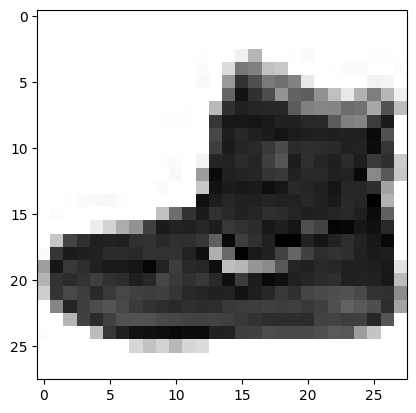

In [26]:
plt.imshow(x_train[0], cmap=plt.cm.binary) # plt.cm.gray
plt.show()

In [27]:
def plot_fastion_nmist(arr, ncols=10):
  # arr:(n_samples, width, height) shape의 3차원 배열
  # ncols: subplot axis의 컬럼 개수.
  n = len(arr) # 출력할 이미지 개수.
  nrows = int(np.ceil(n/ncols)) # supplot axis의 행 개수
  fig, axes = plt.subplots(nrows, ncols, figsize=(ncols,nrows))
  for i in range(nrows):
    for j in range(ncols):
      idx = i*ncols+j # 배열 arr에서 선택할 이미지의 인덱스
      if nrows==1 or ncols ==1: # axes는 1차원 배열
        if idx <n:
          axes[idx].imshow(arr[idx], cmap=plt.cm.binary)
        axes[idx].axis('off')
      else: # axes는 2차원 배열
        if idx <n:
          axes[i,j].imshow(arr[idx],cmap=plt.cm.binary)
        axes[i,j].axis('off')
  plt.show()

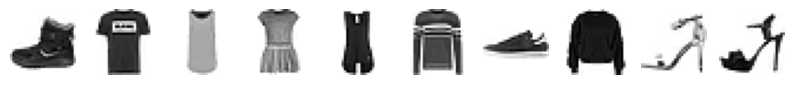

In [28]:
plot_fastion_nmist(x_train[:10])
#

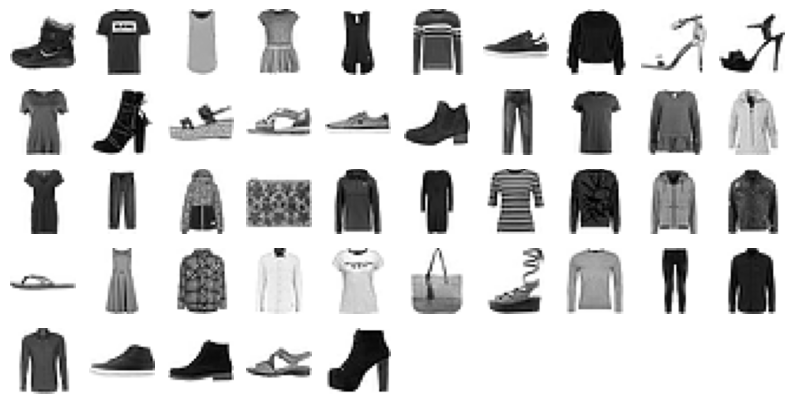

In [29]:
plot_fastion_nmist(x_train[:45])
#

# 훈련 셋 스케일, 훈련/검증 분리

In [30]:
# 훈련 셋의 스케일을 0~1 사이의 값으로 변경. -> SGDClassifier의 성능 향상을 위해 스케일링을 진행.
x_train_scaled  = x_train/255

In [31]:
# 훈련 셋과 훈련 레이블을 훈련/검증으로 분리
train_input, val_input, train_target, val_target= train_test_split(x_train_scaled, y_train,
                                                                   test_size=0.2, random_state=42,
                                                                   stratify=y_train)

In [32]:
train_input.shape

(48000, 28, 28)

In [33]:
train_target.shape

(48000,)

# SGD Classifier

In [34]:
# 모델 생성
sgd=SGDClassifier(loss='log_loss', random_state=42,n_jobs=-1) # log_loss : 확률계산


In [35]:
# 모델 훈련
# sgd.fit(X=train_input,y=train_target) # 사이킷런 3차원 이상 불가 2차원 배열이용해야한다
sgd.fit(X=train_input.reshape((48_000,-1)),y=train_target)

SGDClassifier(loss='log_loss', n_jobs=-1, random_state=42)

In [36]:
sgd.coef_.shape

(10, 784)

In [37]:
sgd.coef_

array([[-7.70603663e-04,  2.72508248e-03, -3.00035463e-03, ...,
        -1.17690620e-01, -1.32566646e-01,  1.00472625e-02],
       [-2.48479624e-05,  9.32783836e-04, -2.03729836e-03, ...,
        -4.20798291e-02,  5.03346995e-02, -9.55232307e-03],
       [-3.55408691e-04,  2.15568460e-03, -2.11453328e-02, ...,
         7.36715033e-01,  3.44064688e-01,  1.03963915e-01],
       ...,
       [-8.99306976e-09, -4.83423496e-07, -3.95766709e-05, ...,
        -1.48104337e-02,  3.42542873e-02, -5.40338988e-03],
       [-2.42874708e-03,  1.30332774e-03, -3.62625491e-03, ...,
        -4.74249056e-01, -4.00274810e-01, -7.60014557e-02],
       [-3.16320637e-06,  2.96615865e-04,  2.48651463e-04, ...,
        -2.39997785e-01,  3.66218352e-01,  6.55158673e-02]])

In [38]:
sgd.intercept_.shape

(10,)

In [39]:
sgd.intercept_

array([ -1.54024535,  -4.97085256,  -2.45411884,  -1.5496291 ,
        -4.94592029,   3.66151889,  -1.47955462,  -1.90241534,
        -4.40078057, -25.19876253])

In [40]:
# 각 클래스가 될 확률
predict_probs = sgd.predict_proba(X=train_input.reshape((48_000,-1)))

In [41]:
predicts = sgd.predict(X=train_input.reshape((48_000,-1)))

In [42]:
predicts[:2]

array([6, 0], dtype=uint8)

In [43]:
accuracy_score(y_true=train_target, y_pred=predicts) # 훈련 셋 정확도

0.8518125

In [44]:
# 검증 셋 평가
val_input_2d= val_input.reshape((12_000,-1)) # 3d 배열 -> 2d 배열
val_predicts =sgd.predict(X=val_input_2d) # 검증 셋 예측값
accuracy_score(y_true=val_target, y_pred=val_predicts) # 검증 셋 정확도
#

0.8468333333333333

# 입력층과 출력층만 갖는 신경망

In [45]:
train_input_2d=train_input.reshape((48_000,-1))

In [46]:
train_input_2d.shape

(48000, 784)

In [47]:
# 입력층(input layer)
inputs=keras.Input(shape=(784,))

In [48]:
# 출력층(output layer)
dense=keras.layers.Dense(units=10,activation='softmax')

In [49]:
# 완전 연결 신경망
model=keras.Sequential(layers=[inputs,dense])

In [50]:
model.summary()
# 784* 10 +10

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.compile(optimizer=keras.optimizers.SGD(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_crossentropy])

In [52]:
# 신경망 모델 훈련
model.fit(x=train_input_2d, y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.0322 - sparse_categorical_crossentropy: 1.0322
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7071 - sparse_categorical_crossentropy: 0.7071
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6362 - sparse_categorical_crossentropy: 0.6362
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5973 - sparse_categorical_crossentropy: 0.5973
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5716 - sparse_categorical_crossentropy: 0.5716
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5530 - sparse_categorical_crossentropy: 0.5530
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5391 - sparse_categorical_crossentropy: 0.5391
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5277 - sparse_categorical_crossentropy: 0.5277
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.5182 - sparse_categorical_crossentropy: 0.5182
Epoch 10/10
750/750

In [53]:
# 훈련된 신경망 모델이 찾은 모델 파라미터들(가중치, weights)
model.weights # kernel, bias

[<Variable path=sequential_2/dense_4/kernel, shape=(784, 10), dtype=float32, value=[[ 0.04962699  0.04231     0.04003769 ...  0.00895329  0.02804243
   -0.08449692]
  [ 0.03954108 -0.02166217  0.0015759  ... -0.01720756  0.04631884
    0.01737909]
  [-0.02463682 -0.02017551  0.03223227 ...  0.00188437  0.04550665
   -0.05943962]
  ...
  [-0.00111249 -0.05003097  0.03140221 ... -0.04686061 -0.02202424
    0.07243949]
  [ 0.05833395  0.03147022 -0.03197386 ... -0.01335848  0.05948598
    0.05683973]
  [-0.03377025 -0.02902581  0.02535583 ...  0.02536936 -0.01468805
    0.02354475]]>,
 <Variable path=sequential_2/dense_4/bias, shape=(10,), dtype=float32, value=[ 0.10103855 -0.07828884 -0.1109801   0.01360808 -0.4739104   1.126554
   0.25049648 -0.09407292 -0.24385133 -0.490592  ]>]

In [54]:
predicts =model.predict(x=train_input_2d)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step


In [55]:
predicts.shape #> (48,000, 10) = (n_samples, n_classes)

(48000, 10)

In [56]:
predicts[:2]

array([[7.8055812e-03, 5.3345202e-04, 1.6553146e-01, 1.7625796e-02,
        7.7404886e-02, 3.6424612e-05, 7.2469056e-01, 1.8888722e-06,
        6.3561378e-03, 1.3946672e-05],
       [5.6638187e-01, 3.6674881e-04, 1.5385052e-03, 1.0119245e-02,
        1.5349561e-02, 1.4934793e-07, 4.0590248e-01, 4.0068258e-07,
        3.3778703e-04, 3.2313669e-06]], dtype=float32)

In [57]:
# 훈련 셋의 예측 레이블 계산 - 10개의 확률들 중 최댓값의 인덱스.
train_pred_labels =  predicts.argmax(axis=1)

In [58]:
train_pred_labels[:2]

array([6, 0])

In [59]:
accuracy_score(y_true=train_target,y_pred=train_pred_labels)
# 훈련 셋 정확도

0.8310416666666667

In [60]:
model.evaluate(x=train_input_2d, y=train_target)
# loss , accuracy

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.5066 - sparse_categorical_crossentropy: 0.5066


[0.5065833926200867, 0.5065833926200867]

In [61]:
# 검증 셋 정확도
model.evaluate(x=val_input_2d, y=val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4958 - sparse_categorical_crossentropy: 0.4958


[0.4958147406578064, 0.4958147406578064]

# 활성화 함수(Activation Function)

* 활성화 함수: 신경망의 각 층(layer)에서 출력을 내보내는 함수.
* 은닉측(hidden layer)에서 활성화 함수로 선형 함수를 사용하면 여러 개의 층을 연결하는 효과가 없음.
  * 단일 층을 사용하는 것과 같음.
* 은닉측에서는 비선형 함수를 활성화 함수로 사용.  

## Sigmoid 함수

$
\text{sigmoid}(x) = \dfrac{1}{1 + \exp(-x)}
$



In [62]:
xvals=np.arange(-5,5,0.0001)

In [63]:
def sigmoid(x):
  return 1/(1+ np.exp(-x))

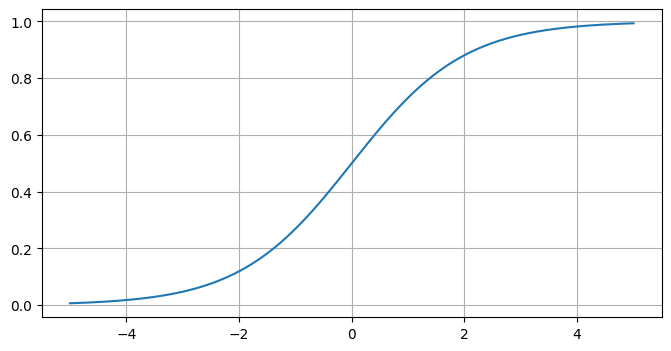

In [64]:
plt.figure(figsize=(8,4))
plt.plot(xvals, sigmoid(xvals))
plt.grid()
plt.show()

In [65]:
def plot_activation_fn(fn):
  xvals=np.arange(-5,5,0.0001)
  yvals=fn(xvals)
  plt.figure(figsize=(8,4))
  plt.plot(xvals, yvals)
  plt.grid()
  plt.show()

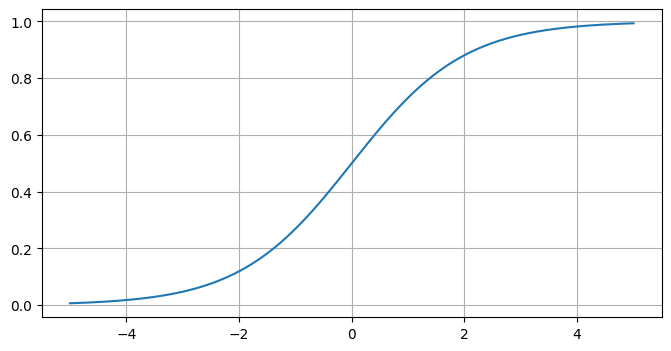

In [66]:
plot_activation_fn(sigmoid)

## Hyperbolic Tangent

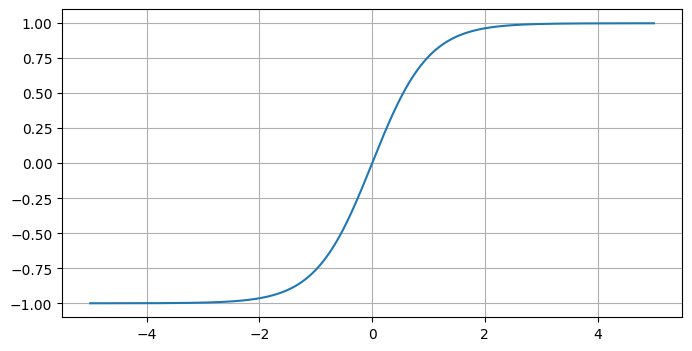

In [67]:
plot_activation_fn(np.tanh)

## ReLu(Rectified Linear Unit)

* 입력값이 양수이면 입력값 그대로 출력을 내보냄.
* 입력값이 음수이면 출력값을 0으로 만듦.
* 이미지를 처리할 때 좋은 성능을 낸다고 알려져 있음.

$
\text{ReLu}(x) =
\begin{cases}
x & \text{for } x \ge 0 \\
0 & \text{for } x \lt 0
\end{cases}
$

In [68]:
def relu(x):
  return np.maximum(x,0) # 둘중 비교해서 큰값 리턴

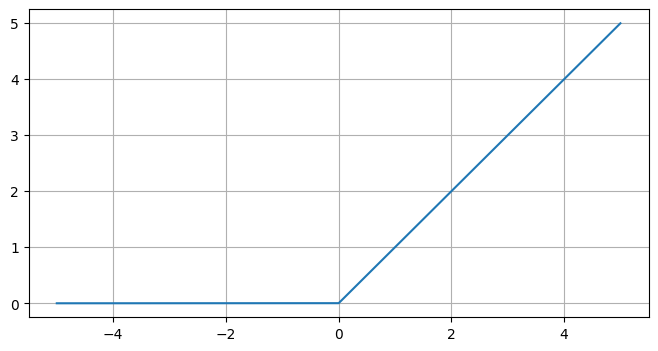

In [69]:
plot_activation_fn(relu)

## Leaky ReLu

$
\text {LeakyReLu}(x, \alpha) =
  \begin{cases}
    x & \text{for } x \ge 0 \\
    \alpha x & \text{for } x \lt 0,\alpha \ge 0
  \end{cases}
$

In [70]:
def leaky_relu(x,alpha=0.1):
  # 0<= alpha <= 1
  return np.maximum(x, alpha * x)

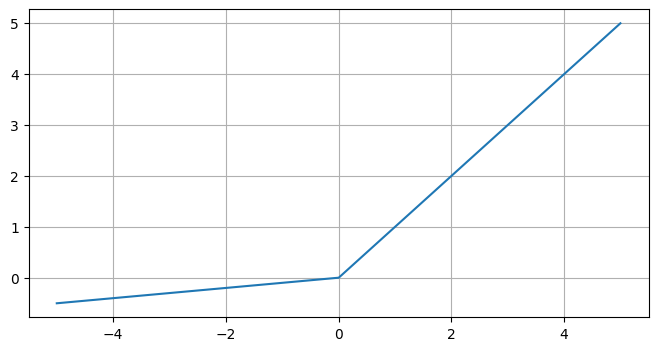

In [71]:
plot_activation_fn(leaky_relu)

## ELU(Exponential Linear Unit)

$
\text{ELU}(x, \alpha) =
  \begin{cases}
    x & \text{for } x \ge 0 \\
    \alpha (\exp(x) - 1) & \text{for } x \lt 0
  \end{cases}
$

In [72]:
def elu(x, alpha=1.0):
  return np.where(x>=0,x,alpha *(np.exp(x)-1))

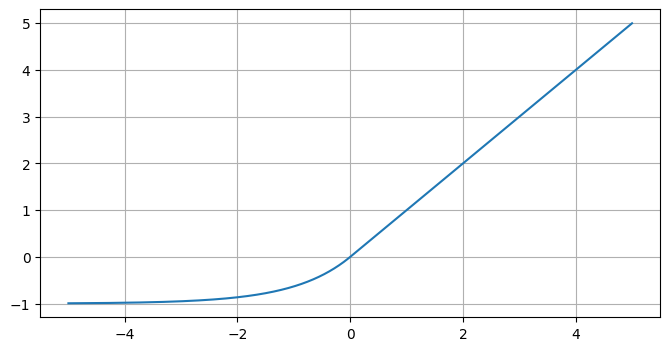

In [73]:
plot_activation_fn(elu)

은닉층에서 활성화 함수 선택: ELU > LeakyReLu > ReLu > tanh > sigmoid

# ReLu를 활성화 함수로 사용하는 은닉층

In [74]:
model =keras.Sequential() # 완전연결 신경망

In [75]:
model.add(keras.Input(shape=(28,28))) # 입력층

In [76]:
# Flatten 층: (28, 28)모양의 배열을 (784, )모양의 1차원 배열로 변환
model.add(keras.layers.Flatten())
# reshape 대안

In [77]:
# 은닉층: 100개의 unit들을 갖는, ReLu 활성화 함수를 사용하는 은닉층을 추가
model.add(keras.layers.Dense(units=100, activation='relu'))

In [78]:
# 출력층: 10개의 클래스로 분류하는 다중 클래스 분류 문제.
model.add(keras.layers.Dense(units=10, activation='softmax'))


In [79]:
model.summary()
# 784*100+100
# 100*10+10

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
# input flatten dense dense
model.compile(optimizer=keras.optimizers.SGD(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [81]:
model.fit(x=train_input, y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.9574 - sparse_categorical_accuracy: 0.6991
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6188 - sparse_categorical_accuracy: 0.7970
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5508 - sparse_categorical_accuracy: 0.8181
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5149 - sparse_categorical_accuracy: 0.8289
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4929 - sparse_categorical_accuracy: 0.8333
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4755 - sparse_categorical_accuracy: 0.8388
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4626 - sparse_categorical_accuracy: 0.8412
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4516 - sparse_categorical_accuracy: 0.8444
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4431 - sparse_categorical_accuracy: 0.8482
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - 

In [82]:
model.evaluate(x=train_input, y=train_target) #훈련셋 평가

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4316 - sparse_categorical_accuracy: 0.8513


[0.4316389262676239, 0.8513333201408386]

In [83]:
model.evaluate(x=val_input, y=val_target) # 검증셋 평가

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4272 - sparse_categorical_accuracy: 0.8537


[0.4272279143333435, 0.8537499904632568]

# Optimizer

**Optimizer(최적화 함수)**

* 손실함수를 최소화 시키는 과정에서 모델 파라미터(가중치)들을 최적화하는 알고리즘.
* 경사하강법(Gradient Descent): 손실함수의 기울기가 줄어드는 방향으로 모델 파라미터들을 최적화 시키는 알고리즘.

$
w_{next} = w_{init} - \text{learning_rate} \cdot \text {gradient}
$

* 아주 큰(깊은) 신경망인 경우는 모델 훈련에서 찾아야 하는 가중치들의 개수가 매우 많음.
* 모델 파라미터(가중치)들의 개수가 많을 수록 훈련 속도가 심각하게 느려질 수 있음.
* 훈련 속도를 빠르게 하는 방법:
  * 좋은 초기화 전략 사용하기
  * 좋은 활성화 함수 사용하기
  * 배치 정규화 사용하기
  * 사전 훈련된 네트워크(신경망)의 일부를 재사용
  * 일반적인 경사 하강법 대신 더 빠른 옵티마이저를 사용하기
* SGD(Stochastic Gradient Descent, 확률적 경사 하강법)의 파라미터 변경 - SGD 변종 옵티마이저
  * learning_rate(학습률) 파라미터를 변경
  * momentum(모멘텀) 파라미터 값을 0보다 큰 값으로 변경 - **모멘텀 최적화(momentum optimization)**  
  * nesterov(네스테로프) 파라미터를 True로 변경 - **네스테로프 가속 경사(NAG, Nesterov Accelerated Gradient)**
* 적응형 학습률(adaptive learning rate)을 사용한 옵티마이저
  * 학습할 때마다 학습률을 변화시킴.
  * RMSprop(Root Mean Squared Propagation): compile 메서드 optimizer 파라미터의 기본값.
  * Adam(Adaptive Momentum Estimation): 모멘텀 최적화 + RMSprop
  * Nadam: Adam + Nesterov
  * AdaGrad: Adam의 변종

## RMSprop 옵티마이저

In [84]:
def create_model(layers=None):
  # layers: keras.layers 객체(예:Dense)들의 배열/리스트. 깊은 신경망(deep neural network)을 만들기 위한 레이어.
  model = keras.Sequential() # 완전연결 신경망
  model.add(keras.Input(shape=(28,28))) # 입력층
  model.add(keras.layers.Flatten()) # Flatten layer: (28, 28) >> (784, )
  model.add(keras.layers.Dense(units=100, activation='elu')) # 첫번째 은닉층
  if layers: # 아구먼트로 전달된 은닉층들이 있으면
    for l in layers:
      model.add(l)
  model.add(keras.layers.Dense(units=10,activation='softmax'))

  return model

In [85]:
model1 =create_model()

In [86]:
model1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
model.compile(optimizer=keras.optimizers.RMSprop(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [88]:
model.fit(x=train_input,y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4846 - sparse_categorical_accuracy: 0.8317
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4066 - sparse_categorical_accuracy: 0.8552
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3655 - sparse_categorical_accuracy: 0.8667
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3404 - sparse_categorical_accuracy: 0.8774
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3194 - sparse_categorical_accuracy: 0.8825
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3056 - sparse_categorical_accuracy: 0.8871
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.2917 - sparse_categorical_accuracy: 0.8931
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2815 - sparse_categorical_accuracy: 0.8966
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2713 - sparse_categorical_accuracy: 0.9002
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - 

## Adam 파라미터:

* learning_rate: 학습률
* beta_1: 모멘텀
* beta_2: RMSprop의 rho와 비슷

In [89]:
model2=create_model()

In [90]:
model2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [91]:
model2.compile(optimizer=keras.optimizers.Adam(),
               loss=keras.losses.sparse_categorical_crossentropy,
               metrics=[keras.metrics.sparse_categorical_accuracy])

In [92]:
model2.fit(x=train_input, y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5520 - sparse_categorical_accuracy: 0.8084
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.4198 - sparse_categorical_accuracy: 0.8518
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3746 - sparse_categorical_accuracy: 0.8659
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3494 - sparse_categorical_accuracy: 0.8738
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3297 - sparse_categorical_accuracy: 0.8798
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3133 - sparse_categorical_accuracy: 0.8839
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.3009 - sparse_categorical_accuracy: 0.8903
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2889 - sparse_categorical_accuracy: 0.8933
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2780 - sparse_categorical_accuracy: 0.8962
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - 

In [93]:
model2.evaluate(x=train_input,y=train_target)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2470 - sparse_categorical_accuracy: 0.9080


[0.24695941805839539, 0.9079583287239075]

In [94]:
model2.evaluate(x=val_input,y=val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3058 - sparse_categorical_accuracy: 0.8894


[0.3058255612850189, 0.8894166946411133]

# 모델의 저장과 복원

`History`객체: 신경망 모델을 훈련(fit)시키는 과정(각각의 epochs)의 기록을 담고 있는 객체. `fit`메서드의 리턴 타입.

In [95]:
model=create_model()
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
model.compile(optimizer=keras.optimizers.RMSprop(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [97]:
result=model.fit(x=train_input,y=train_target,batch_size=64,epochs=10,
                 validation_data=[val_input, val_target])

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.5722 - sparse_categorical_accuracy: 0.7966 - val_loss: 0.4362 - val_sparse_categorical_accuracy: 0.8418
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4185 - sparse_categorical_accuracy: 0.8507 - val_loss: 0.3755 - val_sparse_categorical_accuracy: 0.8663
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3766 - sparse_categorical_accuracy: 0.8628 - val_loss: 0.3606 - val_sparse_categorical_accuracy: 0.8734
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3508 - sparse_categorical_accuracy: 0.8700 - val_loss: 0.3770 - val_sparse_categorical_accuracy: 0.8656
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3313 - sparse_categorical_accuracy: 0.8789 - val_loss: 0.3342 - val_sparse_categorical_accuracy: 0.8802
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3159 - sparse_categorical_accuracy: 0.8858 - val_loss: 0.3528 - val_sparse_categorical_accuracy: 0.8730
Epoc

In [98]:
print(type(result))

<class 'keras.src.callbacks.history.History'>


In [99]:
history=result.history
history #> dict 타입 객체 - 훈련 손실, 훈련 정확도, 검증 손실, 검증 정확도

{'loss': [0.572191596031189,
  0.4185328781604767,
  0.3765576183795929,
  0.35075682401657104,
  0.3312622010707855,
  0.3159298598766327,
  0.30383843183517456,
  0.2928915321826935,
  0.2824656069278717,
  0.2756004333496094],
 'sparse_categorical_accuracy': [0.7966458201408386,
  0.8507083058357239,
  0.8628333210945129,
  0.8699583411216736,
  0.8788750171661377,
  0.885770857334137,
  0.8885416388511658,
  0.8920833468437195,
  0.8946458101272583,
  0.8982916474342346],
 'val_loss': [0.4361874461174011,
  0.3754810690879822,
  0.3606491982936859,
  0.377030611038208,
  0.3341701328754425,
  0.3528454601764679,
  0.35119932889938354,
  0.33169564604759216,
  0.31830310821533203,
  0.31917592883110046],
 'val_sparse_categorical_accuracy': [0.8417500257492065,
  0.8663333058357239,
  0.8734166622161865,
  0.8655833601951599,
  0.8801666498184204,
  0.8730000257492065,
  0.875333309173584,
  0.8821666836738586,
  0.887499988079071,
  0.8863333463668823]}

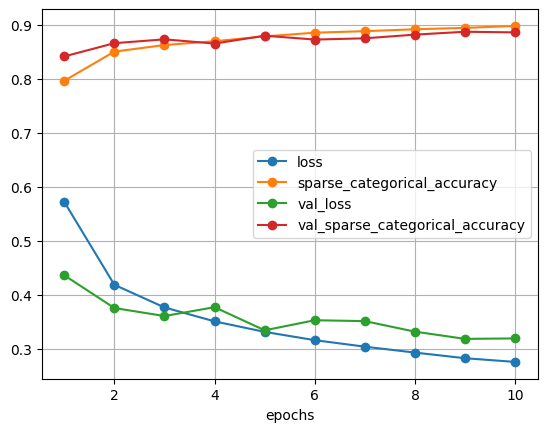

In [100]:
epochs= np.arange(1,11)
for k,v in history.items(): #dict에서 items를 해야 key & value를 뽑을수있다
  plt.plot(epochs, v, 'o-', label=k)
plt.legend()
plt.grid()
plt.xlabel('epochs')
plt.show()

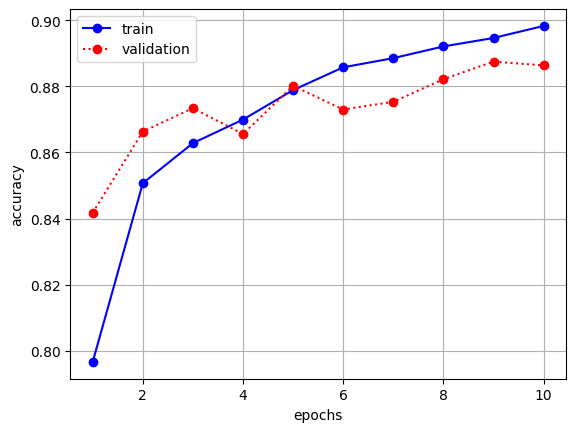

In [101]:
# 에포크에 따른 정확도 변화
plt.plot(epochs, history['sparse_categorical_accuracy'], 'bo-',label='train')
plt.plot(epochs, history['val_sparse_categorical_accuracy'], 'ro:', label='validation')
plt.legend()
plt.grid()
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.show()

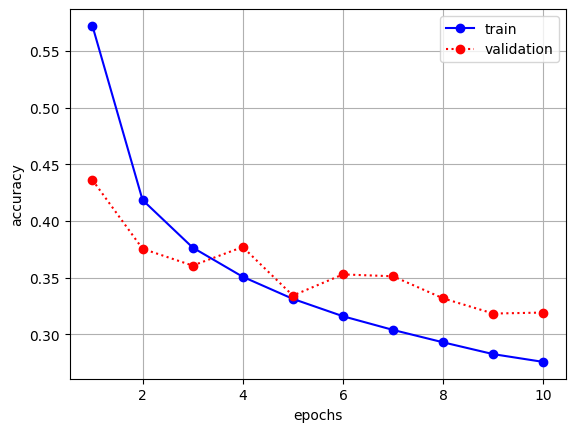

In [102]:
# 검증셋에서의 점수가 2번 3번 떨어지면 바로 그 전 점수가 최적의 점수라는 말이다 이말이야
# epochs에 따른 손실 변화
plt.plot(epochs, history['loss'], 'bo-',label='train')
plt.plot(epochs, history['val_loss'], 'ro:', label='validation')
plt.legend()
plt.grid()
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.show()

## Adam 옵티마이저를 사용, epochs 20회, 훈련/검증 셋의 손실 그래프

In [103]:
# model2.compile(optimizer=keras.optimizers.Adam(),
#               loss=keras.losses.sparse_categorical_crossentropy,
#               metrics=[keras.metrics.sparse_categorical_accuracy])
# result2=model2.fit(x=train_input,y=train_target,batch_size=64,epochs=20,
#                  validation_data=[val_input, val_target])
model = create_model()
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])
result = model.fit(x=train_input, y=train_target, batch_size=64, epochs=20,
                   validation_data=[val_input, val_target])


Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5400 - sparse_categorical_accuracy: 0.8116 - val_loss: 0.4488 - val_sparse_categorical_accuracy: 0.8421
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.4106 - sparse_categorical_accuracy: 0.8539 - val_loss: 0.3867 - val_sparse_categorical_accuracy: 0.8627
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.3721 - sparse_categorical_accuracy: 0.8651 - val_loss: 0.3571 - val_sparse_categorical_accuracy: 0.8706
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3481 - sparse_categorical_accuracy: 0.8718 - val_loss: 0.3504 - val_sparse_categorical_accuracy: 0.8750
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3282 - sparse_categorical_accuracy: 0.8813 - val_loss: 0.3460 - val_sparse_categorical_accuracy: 0.8738
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3107 - sparse_categorical_accuracy: 0.8849 - val_loss: 0.3261 - val_sparse_categorical_accuracy: 0.8813
Epoc

In [104]:
history=result.history
history

{'loss': [0.5399584770202637,
  0.4105730354785919,
  0.37210285663604736,
  0.34814244508743286,
  0.32824280858039856,
  0.3107468783855438,
  0.29818499088287354,
  0.2838192582130432,
  0.27187061309814453,
  0.2643950879573822,
  0.2562090754508972,
  0.2487371414899826,
  0.23886314034461975,
  0.23123516142368317,
  0.22740399837493896,
  0.2180519551038742,
  0.2120184302330017,
  0.20865148305892944,
  0.2036011517047882,
  0.19774559140205383],
 'sparse_categorical_accuracy': [0.8115624785423279,
  0.8539166450500488,
  0.8650833368301392,
  0.8718125224113464,
  0.8813333511352539,
  0.8849166631698608,
  0.8887291550636292,
  0.8961874842643738,
  0.8989999890327454,
  0.9019791483879089,
  0.9051458239555359,
  0.9079166650772095,
  0.9105416536331177,
  0.9133958220481873,
  0.9160833358764648,
  0.9180208444595337,
  0.9209791421890259,
  0.9223541617393494,
  0.9241874814033508,
  0.9256458282470703],
 'val_loss': [0.44882410764694214,
  0.386707603931427,
  0.357068836

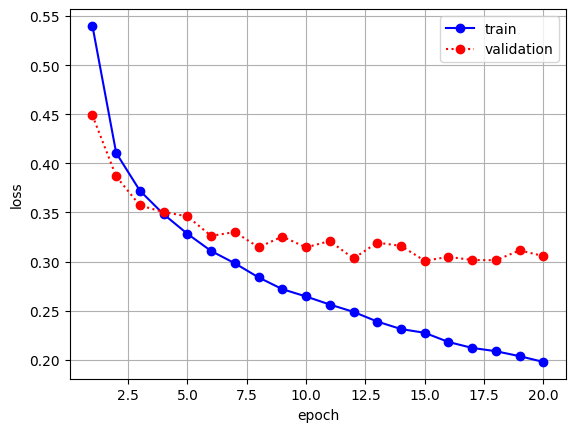

In [105]:
# # epochs에 따른 손실 변화
# plt.plot(epochs, history['loss'], 'bo-',label='train')
# plt.plot(epochs, history['val_loss'], 'ro:', label='validation')
# plt.legend()
# plt.grid()
# plt.xlabel('epochs')
# plt.ylabel('accuracy')
# plt.show()
history = result.history
epochs = np.arange(1, 21)
plt.plot(epochs, history['loss'], 'bo-', label='train')
plt.plot(epochs, history['val_loss'], 'ro:', label='validation')
plt.legend()
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [106]:
model3=create_model()
model3.compile(optimizer=keras.optimizers.RMSprop(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])
result3=model3.fit(x=train_input,y=train_target,batch_size=64,epochs=20,
                 validation_data=[val_input, val_target])

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5656 - sparse_categorical_accuracy: 0.7991 - val_loss: 0.4248 - val_sparse_categorical_accuracy: 0.8467
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4177 - sparse_categorical_accuracy: 0.8485 - val_loss: 0.3793 - val_sparse_categorical_accuracy: 0.8635
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3745 - sparse_categorical_accuracy: 0.8634 - val_loss: 0.3696 - val_sparse_categorical_accuracy: 0.8681
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3496 - sparse_categorical_accuracy: 0.8723 - val_loss: 0.3609 - val_sparse_categorical_accuracy: 0.8685
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3308 - sparse_categorical_accuracy: 0.8787 - val_loss: 0.3583 - val_sparse_categorical_accuracy: 0.8709
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3170 - sparse_categorical_accuracy: 0.8832 - val_loss: 0.3245 - val_sparse_categorical_accuracy: 0.8857
Epoc

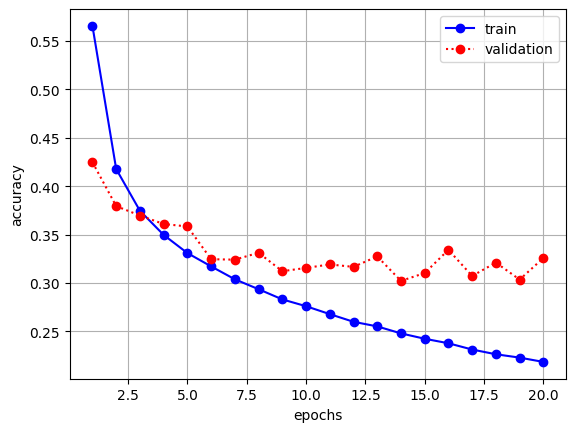

In [107]:
# epochs에 따른 손실 변화
history = result3.history
epochs = np.arange(1, 21)
plt.plot(epochs, history['loss'], 'bo-',label='train')
plt.plot(epochs, history['val_loss'], 'ro:', label='validation')
plt.legend()
plt.grid()
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.show()

# Dropout

* 모델의 과대적합을 줄이는 방법
* 훈련 과정(epoch)에서 일부 유닛(unit)의 출력을 0으로 만드는 것.
    * 다음 계층(layer)로 출력값을 전달하지 않음.
* 각 epoch마다 출력을 0으로 만드는 유닛은 무작위로 선택.
    

In [108]:
# 은닉층 뒤에 30% 비율로 출력을 0으로 만드는 Dropout 계층을 추가
model = create_model(layers=[keras.layers.Dropout(rate=0.3)])
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [121]:
model.compile(optimizer=keras.optimizers.Adam(),
               loss=keras.losses.sparse_categorical_crossentropy,
               metrics=[keras.metrics.sparse_categorical_accuracy])

In [122]:
result=model.fit(x=train_input,y=train_target,batch_size=64,epochs=20,
                  validation_data=[val_input,val_target])

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.5991 - sparse_categorical_accuracy: 0.7915 - val_loss: 0.4675 - val_sparse_categorical_accuracy: 0.8322
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.4593 - sparse_categorical_accuracy: 0.8363 - val_loss: 0.3969 - val_sparse_categorical_accuracy: 0.8594
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.4276 - sparse_categorical_accuracy: 0.8468 - val_loss: 0.3797 - val_sparse_categorical_accuracy: 0.8655
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.4055 - sparse_categorical_accuracy: 0.8529 - val_loss: 0.3606 - val_sparse_categorical_accuracy: 0.8695
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.3884 - sparse_categorical_accuracy: 0.8589 - val_loss: 0.3487 - val_sparse_categorical_accuracy: 0.8775
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3769 - sparse_categorical_accuracy: 0.8637 - val_loss: 0.3580 - val_sparse_categorical_accuracy: 0.8712
Epo

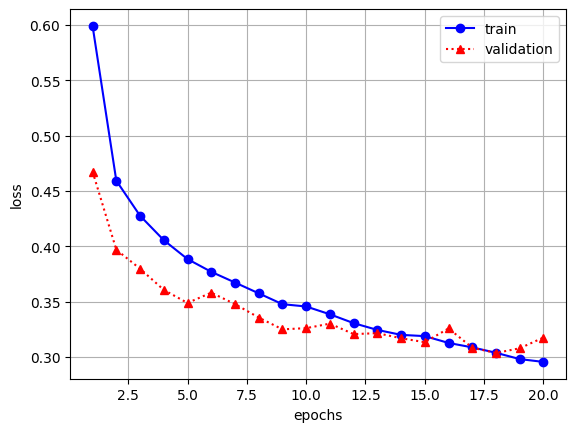

In [123]:
history=result.history
epochs=np.arange(1,21)
plt.plot(epochs,history['loss'],'bo-',label='train')
plt.plot(epochs,history['val_loss'],'r^:',label='validation')
plt.legend()
plt.grid()
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()


## 모델 저장과 복원

In [124]:
# 훈련 (fit)이 끝난 모델 객체는 weights 특성이 결정됨.
model.weights #> 첫번째 은닉층의 kernel과 bias, 출력층의 kernel과 bias를 저장하는 배열.

[<Variable path=sequential_9/dense_17/kernel, shape=(784, 100), dtype=float32, value=[[ 0.20688652  0.13586211  0.1452258  ...  0.26544204  0.1804943
    0.00729726]
  [-0.10716189  0.02402873 -0.33172965 ... -0.27882868 -0.13688618
    0.5241041 ]
  [ 0.4091398  -0.15100938 -0.15639699 ... -0.18619531  0.13967007
    0.29561728]
  ...
  [-0.34211123  0.09161945  0.02921634 ...  0.2913949  -0.0826788
   -0.09880504]
  [-0.11753301  0.04328171  0.25723538 ...  0.6163248  -0.09919624
   -0.75120777]
  [-0.12834531  0.1868313   0.18392132 ...  0.41634285 -0.07351207
   -0.3917003 ]]>,
 <Variable path=sequential_9/dense_17/bias, shape=(100,), dtype=float32, value=[-0.08959167  0.5374449  -0.4737301  -0.47196123  0.0942268   0.15477931
  -0.1476886   0.08292569 -0.36805543 -0.23517616  0.47547665 -0.3297282
   0.3668958   0.70627505 -0.3890154  -0.22394143 -0.00231912 -0.04906403
   0.4825245   0.60194814  0.08165901  0.25935256  0.16761106 -0.44801658
  -0.2854521  -0.21423234 -0.32763854 

In [125]:
model.evaluate(x=train_input,y=train_target) # 훈련 셋 손실, 정확도

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2585 - sparse_categorical_accuracy: 0.9026


[0.25846603512763977, 0.9026041626930237]

In [126]:
model.evaluate(x=val_input,y=val_target) # 검증 셋 손실, 정확도

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3175 - sparse_categorical_accuracy: 0.8854


[0.3174890875816345, 0.8854166865348816]

## 모델 저장

In [127]:
# 모델을 저장하기 위한 구글 드라이브 폴더 경로
path='/content/drive/MyDrive/Colab Notebooks/lab_python/deeplearning'

# 모델 파라미터들만 저장하는 파일의 확장자는 '.weights.h5'
weights_file =path + '/model1.weights.h5'
# 모델의 구조와 파라미터들을 모두 저장하는 파일의 확장자는 '.keras'
model_file = path + '/model1.keras'

In [128]:
# 모델 파라미터들만 저장
model.save_weights(weights_file)

In [129]:
# 모델 전체를 저장
model.save(model_file)

In [12]:
# import keras
# import numpy as np

# def create_model(layers=None):
#   # layers: keras.layers 객체(예:Dense)들의 배열/리스트. 깊은 신경망(deep neural network)을 만들기 위한 레이어.
#   model = keras.Sequential() # 완전연결 신경망
#   model.add(keras.Input(shape=(28,28))) # 입력층
#   model.add(keras.layers.Flatten()) # Flatten layer: (28, 28) >> (784, )
#   model.add(keras.layers.Dense(units=100, activation='elu')) # 첫번째 은닉층
#   if layers: # 아구먼트로 전달된 은닉층들이 있으면
#     for l in layers:
#       model.add(l)
#   model.add(keras.layers.Dense(units=10,activation='softmax'))

#   return model

# # Model saving setup (re-defining path and weights_file as they were not executed in cell OCAuCGwCn1q9)
# path = '/content/drive/MyDrive/Colab Notebooks/lab_python/deeplearning'
# weights_file = path + '/model1.weights.h5'
# model_file = path + '/model1.keras'

# # Load and preprocess data
# (x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
# x_train_scaled = x_train / 255
# from sklearn.model_selection import train_test_split
# train_input, val_input, train_target, val_target = train_test_split(x_train_scaled, y_train,
#                                                                    test_size=0.2, random_state=42,
#                                                                    stratify=y_train)

# # # 모델 파라미터와 같은 구조의 모델을 먼저 생성
# model = create_model(layers=[keras.layers.Dropout(rate=0.3)])

# # Compile the model (using Adam optimizer as seen in model2's compilation and fitting)
# model.compile(optimizer=keras.optimizers.Adam(),
#               loss=keras.losses.sparse_categorical_crossentropy,
#               metrics=[keras.metrics.sparse_categorical_accuracy])

# # Fit the model (training is necessary before saving weights)
# # Using parameters similar to cell CdZ0oXDcmJjZ
# result = model.fit(x=train_input, y=train_target, batch_size=64, epochs=20,
#                    validation_data=[val_input, val_target])

# # Now save the model weights
# model.save_weights(weights_file)

# # You can also save the entire model (architecture + weights + optimizer state)
# model.save(model_file)
# print(f"Model weights saved to: {weights_file}")
# print(f"Full model saved to: {model_file}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5947 - sparse_categorical_accuracy: 0.7908 - val_loss: 0.4398 - val_sparse_categorical_accuracy: 0.8444
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4576 - sparse_categorical_accuracy: 0.8369 - val_loss: 0.4051 - val_sparse_categorical_accuracy: 0.8530
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.4261 - sparse_categorical_accuracy: 0.8470 - val_loss: 0.3828 - val_sparse_categorical_accuracy: 0.8624
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.4031 - sparse_categorical_accuracy: 0.8545 - val_loss: 0.3602 - val_sparse_categorical_accuracy: 0.8711
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3928 - sparse_categorical_accuracy: 0.8586 - val_loss: 0.3551 - val_sparse_categorical

## 모델 복원

저장된 파일에서 불러오기

### 모델 파라미터(가중치)들만 저장한 파일(*weights.h5)에서 복원

In [130]:
# 모델 파라미터와 같은 구조의 모델을 먼저 생성
model_restore = create_model(layers=[keras.layers.Dropout(rate=0.3)])

In [131]:
# 생성된 모델에서 load_weights 매서드를 호출, 아규먼트는 가중치가 저장된 파일 이름.
model_restore.load_weights(weights_file)

(주의)
* 모델 파라미터(가중치)들만 복원한 경우에는 모델이 컴파일되지 않은 상태.
* 손실 함수, 평가 지표가 무엇인 지 모름.
* `evaluate()` 메서드를 호출할 수 없음.
* `predict()` 메서드는 호출할 수 있음.

In [133]:
# model_restore.evaluate(x=train_input,y=train_target)
#> ValuesError 발생 - 컴파일이 되지 않은 모델.


In [134]:
predicts= model_restore.predict(x=train_input) # 훈련 셋 예측값(10개의 확률)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step


In [135]:
predicts[0]

array([8.23648181e-03, 6.73913155e-06, 9.12520140e-02, 2.51772683e-02,
       4.77837548e-02, 1.31596245e-08, 8.24572504e-01, 1.02043451e-09,
       2.97131436e-03, 1.62106750e-09], dtype=float32)

In [141]:
train_pred_lables =predicts.argmax(axis=1)
train_pred_labels[0] # 10개의 확률들 중 가장 큰 확률의 인덱스를 찾음

np.int64(6)

In [142]:
accuracy_score(y_true=train_target, y_pred=train_pred_labels) # 훈련셋 정확도

0.8310416666666667

In [144]:
val_perdicts = model_restore.predict(x=val_input) # 검증 셋 예측값(10개 확률들)
val_pred_labels = val_perdicts.argmax(axis=1) # 검증 셋 예측 레이블
accuracy_score(y_true=val_target, y_pred=val_pred_labels) # 검증셋 정확도

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


0.8854166666666666

### 모델 구조와 파라미터를 모두 저장한 파일(*.keras)에서 복원하기

확장자가 `.keras`인 파일에서 모델을 복원 할 때는 컴파일까지 수행한 모델을 복원할 수 있음.
`evaluate()` 메서드와 `predict()` 메섣를 모두 사용할 수 있음.

In [145]:
model_restore2 = keras.models.load_model(model_file, compile=True)

In [146]:
model_restore2.evaluate(x=train_input,y=train_target)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2585 - sparse_categorical_accuracy: 0.9026


[0.25846603512763977, 0.9026041626930237]

# Callback과 훈련 조기 종료

**Callback(콜백)**

* `keras.callbacks` 모듈 아래의 클래스들.
* 훈련 과정 중간에 어떤 작업을 수행할 수 있게 만드는 객체.
* `keras.callbacks.ModelCheckpoint` 클래스
  * epoch마다 모델을 파일에 저장할 수 있는 기능을 가지고 있는 클래스
  * `save_best_only` 파라미터를 True로 설정해서 가장 검증 손실이 작은 모델만을 저장 할 수 있음.
* `keras.callbacks.EarlyStopping` 클래스
  * 과대적합이 커지기 전에 훈련ㄴ을 일찍 종료시킬 수 있는 기능을 가지고 있는 클래스
  * `fit()` 메서드에서 설정된 epochs 횟수보다 일찍 모델 훈련을 종료시킬 수 있음.
  * `patience` 파라미터: 검증 셋에서 손실이 몇 번까지 커지는 것을 허용할 지를 설정.  

In [148]:
model = create_model(layers=[keras.layers.Dropout(rate=0.3)])
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [149]:
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [152]:
# 모델체크포인트 콜백 객체 생성
checkpoint_cb=keras.callbacks.ModelCheckpoint(filepath=path + '/best_model.keras',
                                              save_best_only=True)

In [154]:
# 조기종료 콜백 객체 생성
early_stop_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [156]:
# 신경망 모델 훈련
result=model.fit(x=train_input, y=train_target, batch_size=64, epochs=1000,
                 validation_data=[val_input,val_target],
                 callbacks=[checkpoint_cb,early_stop_cb])


Epoch 1/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.5950 - sparse_categorical_accuracy: 0.7914 - val_loss: 0.4431 - val_sparse_categorical_accuracy: 0.8400
Epoch 2/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.4552 - sparse_categorical_accuracy: 0.8374 - val_loss: 0.3950 - val_sparse_categorical_accuracy: 0.8623
Epoch 3/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4238 - sparse_categorical_accuracy: 0.8466 - val_loss: 0.3913 - val_sparse_categorical_accuracy: 0.8592
Epoch 4/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4031 - sparse_categorical_accuracy: 0.8548 - val_loss: 0.3576 - val_sparse_categorical_accuracy: 0.8717
Epoch 5/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.3879 - sparse_categorical_accuracy: 0.8575 - val_loss: 0.3661 - val_sparse_categorical_accuracy: 0.8690
Epoch 6/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.3748 - sparse_categorical_accuracy: 0.8636 - val_loss: 0.3442 - val_sparse_categorical_accurac

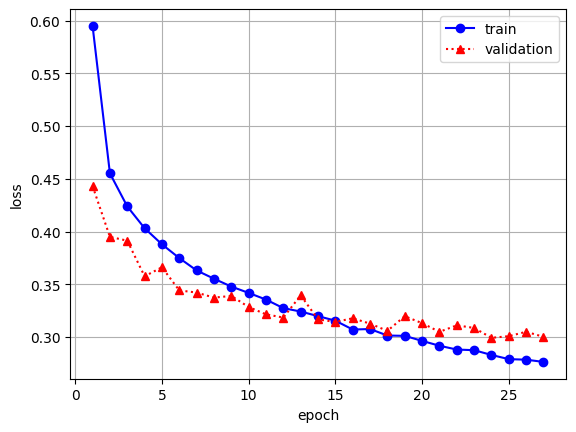

In [158]:
# 훈련/검증 손실 그래프
history=result.history
epochs=np.arange(1,28)

plt.plot(epochs,history['loss'],'bo-',label='train')
plt.plot(epochs,history['val_loss'],'r^:',label='validation')
plt.legend()
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [161]:
# 훈련이 끝난 모델 평가
model.evaluate(x=train_input, y=train_target) # 훈련 셋 평가

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.2289 - sparse_categorical_accuracy: 0.9143


[0.22892645001411438, 0.914312481880188]

In [162]:
model.evaluate(x=val_input, y=val_target) # 검증 셋 평가

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2992 - sparse_categorical_accuracy: 0.8939


[0.29921573400497437, 0.893916666507721]

파일(keras)에 저장된 최적의 모델을 복원

In [163]:
best_model=keras.models.load_model(path + '/best_model.keras', compile=True)

In [164]:
best_model.evaluate(x=val_input,y=val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2992 - sparse_categorical_accuracy: 0.8939


[0.29921573400497437, 0.893916666507721]